# Pipeline de Treinamento: Classificação de Sentimentos
Este notebook apresenta o fluxo completo para a criação de um modelo de Processamento de Linguagem Natural (NLP) focado na análise de avaliações de produtos.

**Objetivo:** Classificar textos em sentimentos **Positivos (1)** ou **Negativos (0)**.

---
## 1. Configuração do Ambiente e Dependências
Nesta etapa, instalamos as bibliotecas necessárias e carregamos o modelo de linguagem `pt_core_news_sm` do spaCy para o processamento do Português.

In [89]:
%pip install pandas scikit-learn seaborn matplotlib imbalanced-learn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
import pickle
import os

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from imblearn.under_sampling import RandomUnderSampler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

if not spacy.util.is_package("pt_core_news_sm"): spacy.cli.download("pt_core_news_sm")

nlp = spacy.load("pt_core_news_sm")


Note: you may need to restart the kernel to use updated packages.


## 2. Função de Pré-processamento

Para que o modelo aprenda padrões relevantes, aplicamos:
1. **Lematização:** Redução das palavras à sua raiz (ex: "compramos" -> "comprar").
2. **Remoção de Stopwords:** Descarte de palavras comuns que não agregam sentimento (artigos, preposições).
3. **Limpeza:** Remoção de pontuações e normalização para minúsculas.

In [90]:
def preprocess_pt(text):
    if not isinstance(text, str): 
        return ""
    
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.is_space]
    return " ".join(tokens)

## 3. Exploração e Limpeza (EDA)

Nesta etapa, realizamos a leitura dos dados brutos e aplicamos as primeiras transformações para garantir a qualidade do dataset antes do treinamento.

### Procedimentos realizados:

* **Leitura do Dataset:** Carregamento do arquivo CSV contendo as avaliações.
* **Tratamento de Valores Ausentes:** Remoção de registros que não possuíam o texto da avaliação (`review_text`) ou o rótulo de sentimento (`polarity`), garantindo que o modelo não processe dados nulos.
* **Processamento de Texto (NLP):** Aplicação da função `preprocess_pt` em todo o corpus. Esta etapa converte o texto bruto em uma versão limpa (lematizada e sem ruídos), armazenando o resultado na nova coluna `tweet_text_cleaned`.
* **Tipagem do Target:** Conversão da coluna de sentimento para o tipo inteiro, facilitando a interpretação pelos algoritmos de Machine Learning.
* **Análise de Desbalanceamento:** Verificação da distribuição das classes para identificar se há uma predominância excessiva de um sentimento sobre o outro.

In [91]:
df = pd.read_csv('../data/avaliacoes.csv')

df = df.dropna(subset=['review_text', 'polarity'])

print("Iniciando limpeza do texto...")
df['review_cleaned'] = df['review_text'].apply(preprocess_pt)

df['sentiment'] = df['polarity'].astype(int)

print("Distribuição das classes:")
print(df['sentiment'].value_counts())

Iniciando limpeza do texto...
Distribuição das classes:
sentiment
1    1134
0     467
Name: count, dtype: int64


In [92]:
df.head()

,original_index,review_text,review_text_processed,review_text_tokenized,polarity,rating,kfold_polarity,kfold_rating,review_cleaned,sentiment
0,40021,Produtos de boa qualidade.,produtos de boa qualidade.,"['produtos', 'de', 'boa', 'qualidade']",1.0,5,10,10,produto qualidade,1
1,79498,As lojas lannister até agora foram perfeitas,as lojas lannister ate agora foram perfeitas,"['as', 'lojas', 'lannister', 'ate', 'agora', '...",1.0,5,10,10,loja lannister perfeito,1
3,54718,Cobrei uma posição após os correios informarem...,cobrei uma posicao apos os correios informarem...,"['cobrei', 'uma', 'posicao', 'apos', 'os', 'co...",0.0,1,10,10,cobrar correio informar receber produto empres...,0
4,58711,Por enquanto td certo. Ainda não testei o prod...,por enquanto td certo. ainda nao testei o prod...,"['por', 'enquanto', 'td', 'certo', 'ainda', 'n...",1.0,5,10,10,td certo testar produto recebi,1
5,73628,Tive problemas mandei email para devolver a la...,tive problemas mandei email para devolver a la...,"['tive', 'problemas', 'mandei', 'email', 'para...",0.0,1,10,10,problema Mandei email devolver lannister dizer...,0


Nesta etapa, visualizamos a distribuição das classes e estatísticas do vocabulário para validar a qualidade do processamento.

**1. Distribuição de Classes**

É fundamental verificar se o dataset está balanceado. Um desequilíbrio acentuado entre sentimentos positivos e negativos pode enviesar as predições do modelo.

**2. Estatísticas do Vocabulário**

Após a limpeza (remoção de stopwords e pontuação), analisamos o volume de palavras únicas remanescentes. Isso nos dá uma dimensão da complexidade do corpus que será transformado em vetores numéricos.

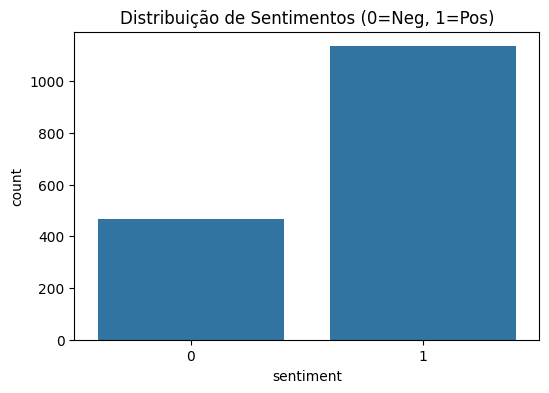

Total de palavras únicas: 2082


In [93]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, legend=False)
plt.title('Distribuição de Sentimentos (0=Neg, 1=Pos)')
plt.show()

todas_palavras = ' '.join(df['review_cleaned']).split()
contagem = Counter(todas_palavras)
print(f"Total de palavras únicas: {len(contagem)}")

Nesta etapa, investigamos as 20 palavras mais recorrentes no corpus após o processo de limpeza e lematização.

Por que esta análise é importante?

* **Validação do Pré-processamento:** Garante que palavras irrelevantes (artigos, preposições) foram removidas com sucesso.
* **Identificação de Temas:** Permite visualizar quais termos são centrais nas avaliações dos usuários.
* **Ajuste de Ruído:** Caso palavras genéricas ainda apareçam com alta frequência, podemos considerá-las para uma lista personalizada de *Stopwords*.

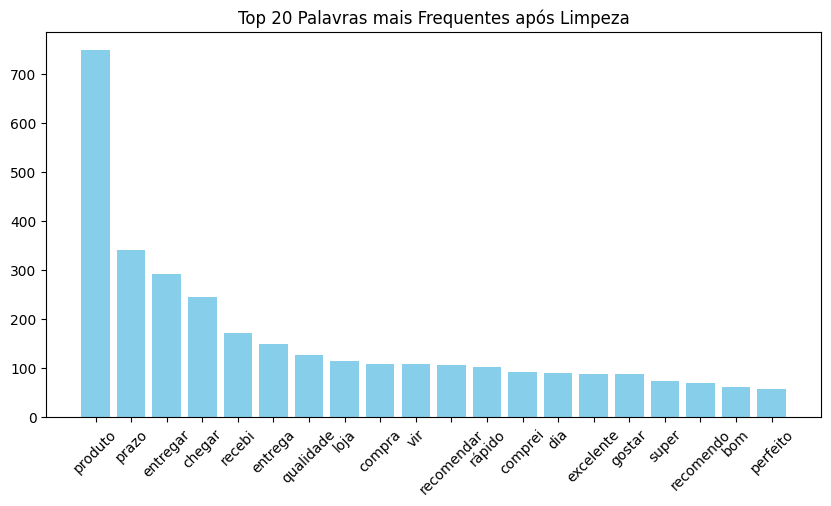

In [94]:
todas_palavras = ' '.join(df['review_cleaned']).split()
contagem = Counter(todas_palavras)
mais_comuns = contagem.most_common(20)

palavras, frequencias = zip(*mais_comuns)
plt.figure(figsize=(10, 5))
plt.bar(palavras, frequencias, color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 20 Palavras mais Frequentes após Limpeza')
plt.show()

**Divisão de Dados:** Separamos 20% dos dados para avaliação final.

**Tratamento de Desbalanceamento:** Utilizamos o `RandomUnderSampler` para garantir que o modelo aprenda de forma equilibrada com ambas as classes (Positivo/Negativo).

In [95]:
rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_res, y_res = rus.fit_resample(df[['review_cleaned']], df['sentiment'])

X_train, X_test, y_train, y_test = train_test_split(
    X_res['tweet_tereview_cleaned'], y_res, test_size=0.2, random_state=42
)

print(f"Dados balanceados! Treinando com {len(X_train)} exemplos.")
print(f"Depois do balanceamento: {y_res.value_counts().to_dict()}")

KeyError: 'tweet_tereview_cleaned'

## 4. Vetorização com TF-IDF
Como algoritmos de Machine Learning operam sobre dados numéricos, utilizamos o **TF-IDF** (*Term Frequency-Inverse Document Frequency*) para transformar os textos processados em vetores.

* **TF (Term Frequency):** Mede a frequência de uma palavra em um documento.
* **IDF (Inverse Document Frequency):** Reduz o peso de palavras que aparecem muito frequentemente em todos os documentos (como "o", "a", "que"), destacando termos mais significativos.

Esta técnica ajuda a capturar a importância relativa de cada palavra no contexto do dataset.

In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## 5. Treinamento do Modelo (Naive Bayes)
Nesta etapa, dividimos os dados em conjuntos de **treino** e **teste** e aplicamos o algoritmo **Multinomial Naive Bayes**.

### Estratégia de Modelagem:

**Classificador Naive Bayes:** Escolhido por sua alta eficiência e bom desempenho histórico em tarefas de classificação de texto e filtragem de spam.

In [ ]:
modelo_final = MultinomialNB(alpha=0.1)
modelo_final.fit(X_train_tfidf, y_train)

y_pred = modelo_final.predict(X_test_tfidf)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        95
           1       0.83      0.88      0.85        92

    accuracy                           0.85       187
   macro avg       0.85      0.85      0.85       187
weighted avg       0.85      0.85      0.85       187



## 6. Avaliação do Modelo

Para entender o desempenho real do classificador, utilizamos um conjunto de métricas que analisam diferentes aspectos dos erros e acertos:

* **Acurácia:** A porcentagem total de previsões corretas.
* **Precisão (Precision):** De todas as vezes que o modelo previu "Positivo", quantas vezes ele realmente acertou? (Evita falsos positivos).
* **Recall (Sensibilidade):** De todos os comentários "Positivos" que realmente existiam, quantos o modelo conseguiu identificar? (Evita falsos negativos).
* **F1-Score:** A média harmônica entre Precisão e Recall, ideal para verificar o equilíbrio do modelo.

In [ ]:
report = classification_report(y_test, y_pred, target_names=['negativo', 'positivo'], output_dict=True)
acc = accuracy_score(y_test, y_pred)

df_report = pd.DataFrame(report).iloc[:-1, :2].T 

fig, ax = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

sns.heatmap(df_report, annot=True, cmap='winter', fmt='.2f', cbar=False, ax=ax[0])
ax[0].set_title('Métricas por Classe (Precisão, Recall, F1-Score)')

ax[1].bar([0], [acc], color='dodgerblue', width=1.0) 

ax[1].set_xlim(-0.5, 0.5) 
ax[1].set_ylim(0, 1.1)

ax[1].set_xticks([0])
ax[1].set_xticklabels(['acurácia'], rotation=0)

ax[1].text(0, acc / 2, f'{acc:.2%}', ha='center', va='center', fontweight='bold', fontsize=14, color='white')
ax[1].set_title('Desempenho Global do Modelo')

for spine in ['top', 'right', 'left']:
    ax[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Matriz de Confusão
Abaixo, visualizamos a matriz de confusão para identificar onde o modelo está confundindo as classes (ex: classificando um comentário negativo como positivo).

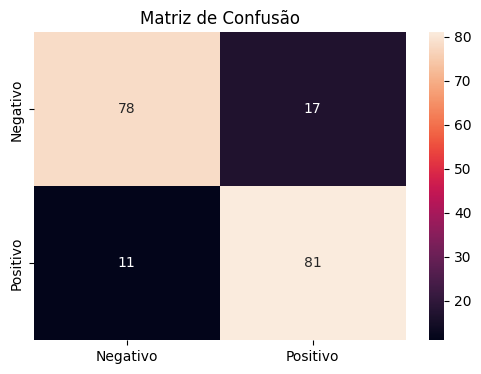

Sensibilidade:  0.88
Especificidade:  0.83


In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='.0f', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusão')
plt.show()

sens = cm[0,0] / (cm[0,0] + cm[1,0])
esp = cm[1,1] / (cm[0,1] + cm[1,1])

print('Sensibilidade: ', round(sens,2))
print('Especificidade: ', round(esp,2))

## 7. Exportação e Persistência do Modelo

Para utilizar o modelo treinado em outros sistemas ou em uma API de produção, precisamos salvar o estado atual do classificador e dos transformadores.

### Componentes Exportados:
1.  **Modelo (Naive Bayes):** O algoritmo já treinado e ajustado.
2.  **Vetorizador (TF-IDF):** Essencial para transformar novos textos de entrada no exato formato que o modelo espera.
3.  **Mapping:** Dicionário auxiliar para converter as saídas numéricas (0, 1) de volta para rótulos legíveis (Negativo, Positivo).

### Estratégia de Organização:
O código garante que os arquivos sejam salvos em uma pasta dedicada (`/models`) na raiz do projeto, utilizando caminhos relativos para garantir que o código funcione em diferentes máquinas sem necessidade de ajustes manuais.

In [ ]:
base_dir = ".." 
folder = 'models'
file_name = 'sentiment_model_v1.pkl'

folder_path = os.path.join(base_dir, folder)
file_path = os.path.join(folder_path, file_name)

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Pasta '{folder_path}' criada com sucesso na raiz do projeto!")

model_package = {
    'model': modelo_final,
    'vectorizer': tfidf,
    'mapping': {0: 'Negativo', 1: 'Positivo'}
}

with open(file_path, 'wb') as f:
    pickle.dump(model_package, f)

print(f"Arquivo salvo com sucesso em: {file_path}")

Arquivo salvo com sucesso em: ..\models\sentiment_model_v1.pkl
